# Phase 04 — Candidate Win-Probability Models

This notebook follows the Project Overview and the instructor's Phase 04 advice in a fixed, auditable order:

1. naïve training-prevalence baseline;
2. standalone logistic regression;
3. random forest rather than a histogram-based tree model.

The candidate with the lowest **validation log loss** is selected independently for female innings 1, female innings 2, male innings 1, and male innings 2. The test period is not used for selection. Log loss is the only performance metric reported.

## Modelling contract

Each delivery row is a post-delivery state. One explicit `state_sequence = 0` state is added before every innings so the first delivery has a prior probability. All learnt preprocessing is fitted on training data only. Numeric predictors are median-imputed with missingness indicators and standardised for logistic regression; `batting_team` and `bowling_team` are one-hot encoded with unknown teams ignored. Random forest receives the same imputed and encoded inputs without numeric scaling.

The naïve candidate is the training-set outcome prevalence. No separate sigmoid calibrator is fitted: logistic regression is an independent candidate model, not a calibration layer for the random forest. A separate expanding-window tuning script compares eight Random Forest configurations without using the test periods. Each track independently selected 500 trees and `max_features=0.25`, while retaining `max_depth=14` and `min_samples_leaf=50`.

In [1]:
from __future__ import annotations

import csv
import gzip
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import sklearn
import yaml
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

PROJECT_ROOT = next(
    (
        path
        for path in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
        if (path / "data" / "raw").exists()
    ),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Open this notebook inside the project repository.")

INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODEL_DIR = PROJECT_ROOT / "models"
METRICS_PATH = PROJECT_ROOT / "reports" / "metrics" / "phase_04_model_performance.json"
PHASE_03_METRICS_PATH = PROJECT_ROOT / "reports" / "metrics" / "phase_03_historical_features.json"

PARAMS = yaml.safe_load((PROJECT_ROOT / "params.yaml").read_text())
VALIDATION = PARAMS["validation"]
MODEL_CONFIG = PARAMS["model"]
CANDIDATES = MODEL_CONFIG["candidates"]
LOGISTIC_CONFIG = MODEL_CONFIG["logistic_regression"]
FOREST_CONFIG = MODEL_CONFIG["random_forest"]
FOREST_TRACK_OVERRIDES = FOREST_CONFIG.get("track_overrides", {})
FOREST_BASE_CONFIG = {
    key: value for key, value in FOREST_CONFIG.items() if key != "track_overrides"
}
PHASE_03_METRICS = json.loads(PHASE_03_METRICS_PATH.read_text())

assert VALIDATION["split_unit"] == "match_id"
assert VALIDATION["split_strategy"] == "chronological"
assert VALIDATION["equal_date_groups"] == "indivisible"
assert np.isclose(
    VALIDATION["train_fraction"] + VALIDATION["validation_fraction"] + VALIDATION["test_fraction"],
    1,
)
assert VALIDATION["primary_metric"] == "log_loss"
assert VALIDATION["secondary_metrics"] == []
assert CANDIDATES == ["naive_baseline", "logistic_regression", "random_forest"]
assert MODEL_CONFIG["selection_metric"] == "validation_log_loss"
assert MODEL_CONFIG["final_evaluation_split"] == "test"
assert MODEL_CONFIG["missing_values"] == {
    "strategy": "median",
    "add_indicator": True,
    "fit_scope": "training_split_only",
}
assert LOGISTIC_CONFIG["standardize"] is True

TRACK_NAMES = [
    "female_innings_1",
    "female_innings_2",
    "male_innings_1",
    "male_innings_2",
]
assert set(FOREST_TRACK_OVERRIDES).issubset(TRACK_NAMES)
TRACK_PATHS = {name: INTERIM_DIR / f"phase_03_{name}.csv.gz" for name in TRACK_NAMES}
for path in TRACK_PATHS.values():
    if not path.exists():
        raise FileNotFoundError(f"Run Phase 03 first; missing {path.name}")

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
print(f"scikit-learn: {sklearn.__version__}")
print(f'Candidates: {" -> ".join(CANDIDATES)}; selection: validation log loss')


scikit-learn: 1.7.2
Candidates: naive_baseline -> logistic_regression -> random_forest; selection: validation log loss


## 1. Date-grouped splits and synthetic pre-innings states

Cutoffs are selected by cumulative match count, not delivery count. The nearest complete calendar-date group to 70% ends training; the nearest group to 85% ends validation. The remaining dates form the test set. Whole matches and equal-date groups cannot cross a boundary.

In [2]:
STATE_AUDIT_COLUMNS = [
    "match_id",
    "match_date",
    "gender",
    "match_innings",
    "source_row",
    "event_sequence",
    "batting_team_win_match",
]


def make_date_group_split(track: pd.DataFrame) -> tuple[pd.Series, dict]:
    matches = track[["match_id", "match_date"]].drop_duplicates()
    assert not matches["match_id"].duplicated().any()
    daily_matches = matches.groupby("match_date").size().sort_index()
    cumulative = daily_matches.cumsum()
    match_count = len(matches)
    train_target = match_count * VALIDATION["train_fraction"]
    validation_end_target = match_count * (
        VALIDATION["train_fraction"] + VALIDATION["validation_fraction"]
    )
    train_end_date = (cumulative - train_target).abs().idxmin()
    validation_end_date = (cumulative - validation_end_target).abs().idxmin()
    assert train_end_date < validation_end_date < daily_matches.index.max()

    date_split = pd.Series("test", index=daily_matches.index, dtype="string")
    date_split.loc[date_split.index <= validation_end_date] = "validation"
    date_split.loc[date_split.index <= train_end_date] = "train"
    split = track["match_date"].map(date_split)
    assert split.notna().all()

    match_check = track[["match_id", "match_date"]].assign(split=split).drop_duplicates()
    assert match_check.groupby("match_id")["split"].nunique().eq(1).all()
    assert match_check.groupby("match_date")["split"].nunique().eq(1).all()
    assert set(match_check["split"]) == {"train", "validation", "test"}

    details = {
        "train_end_date": train_end_date.date().isoformat(),
        "validation_end_date": validation_end_date.date().isoformat(),
        "match_counts": {
            str(k): int(v) for k, v in match_check["split"].value_counts().sort_index().items()
        },
        "date_ranges": {
            split_name: {
                "min": match_check.loc[match_check["split"].eq(split_name), "match_date"]
                .min()
                .date()
                .isoformat(),
                "max": match_check.loc[match_check["split"].eq(split_name), "match_date"]
                .max()
                .date()
                .isoformat(),
            }
            for split_name in ["train", "validation", "test"]
        },
    }
    return split, details


def add_pre_innings_states(track: pd.DataFrame, feature_columns: list[str]) -> pd.DataFrame:
    state_columns = [*STATE_AUDIT_COLUMNS, *feature_columns]
    delivery_states = track[state_columns].copy()
    delivery_states["is_pre_innings_state"] = 0
    delivery_states["state_sequence"] = delivery_states["event_sequence"].astype("int64")

    pre = (
        delivery_states.sort_values(["match_id", "source_row"], kind="stable")
        .groupby("match_id", as_index=False, sort=False)
        .head(1)
        .copy()
    )
    pre["source_row"] = pd.NA
    pre["event_sequence"] = 0
    pre["state_sequence"] = 0
    pre["is_pre_innings_state"] = 1
    zero_state = {
        "innings_score": 0,
        "innings_wickets": 0,
        "wickets_remaining": 10,
        "cumulative_innings_legal_balls": 0,
        "legal_deliveries_remaining": 120,
        "current_run_rate": np.nan,
        "powerplay": 1,
        "middle_overs": 0,
        "death_overs": 0,
        "runs_prev_10_events": 0,
        "wickets_prev_10_events": 0,
    }
    for column, value in zero_state.items():
        pre[column] = value

    if int(track["match_innings"].iloc[0]) == 2:
        pre["runs_to_win"] = pre["target_runs"]
        pre["required_run_rate"] = 6 * pre["target_runs"] / 120
        pre["run_rate_differential"] = np.nan
        pre["target_progress"] = 0.0

    states = pd.concat([pre, delivery_states], ignore_index=True)
    states = states.sort_values(["match_id", "state_sequence"], kind="stable").reset_index(
        drop=True
    )
    assert states.groupby("match_id")["is_pre_innings_state"].sum().eq(1).all()
    assert states.loc[states["is_pre_innings_state"].eq(1), "state_sequence"].eq(0).all()
    assert len(states) == len(track) + track["match_id"].nunique()
    return states


def make_imputer() -> SimpleImputer:
    return SimpleImputer(
        strategy=MODEL_CONFIG["missing_values"]["strategy"],
        add_indicator=MODEL_CONFIG["missing_values"]["add_indicator"],
        keep_empty_features=True,
    )


def make_preprocessor(
    numeric_columns: list[str],
    categorical_columns: list[str],
    *,
    standardize: bool,
) -> ColumnTransformer:
    numeric_steps = [("imputer", make_imputer())]
    if standardize:
        numeric_steps.append(("scaler", StandardScaler()))
    numeric_pipeline = Pipeline(numeric_steps)
    categorical_pipeline = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="most_frequent")),
            (
                "encoder",
                OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            ),
        ]
    )
    return ColumnTransformer(
        [
            ("numeric", numeric_pipeline, numeric_columns),
            ("categorical", categorical_pipeline, categorical_columns),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )


def predict_logistic_probability(pipeline: Pipeline, features: pd.DataFrame) -> np.ndarray:
    return pipeline.predict_proba(features)[:, 1]


# Synthetic split check: matches on the same boundary date cannot be separated.
synthetic = pd.DataFrame(
    {
        "match_id": [1, 2, 3, 4, 5],
        "match_date": pd.to_datetime(
            ["2020-01-01", "2020-01-02", "2020-01-02", "2020-01-03", "2020-01-04"]
        ),
    }
)
synthetic_split, _ = make_date_group_split(synthetic)
assert (
    synthetic.loc[synthetic["match_date"].eq("2020-01-02")]
    .assign(split=synthetic_split)["split"]
    .nunique()
    == 1
)
print("Date-group split, preprocessing, and pre-innings helpers defined.")


Date-group split, preprocessing, and pre-innings helpers defined.


### Training, selection, and final evaluation flow

The test split is deliberately downstream of model selection. Only validation log loss determines which candidate supplies `win_probability_selected`.

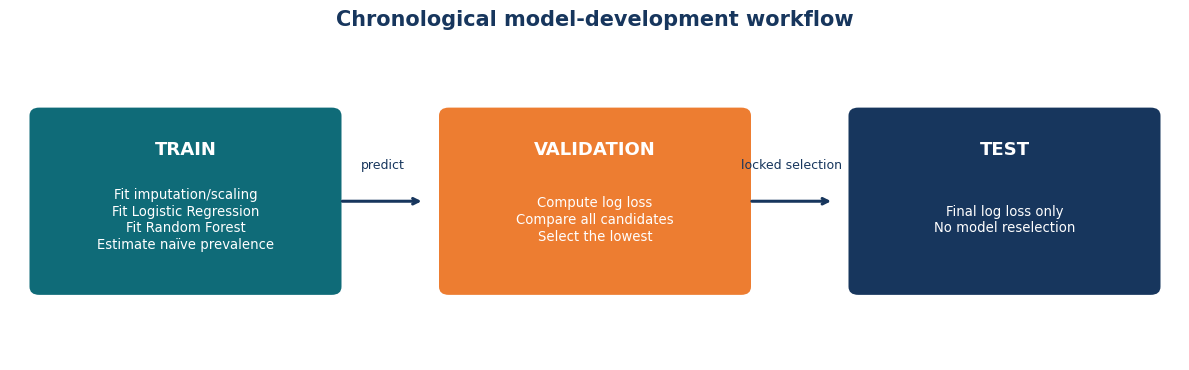

In [3]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

NAVY = "#17365D"
TEAL = "#0F6B78"
ORANGE = "#ED7D31"
LIGHT_BLUE = "#DDEBF7"

fig, ax = plt.subplots(figsize=(12, 3.8))
ax.set_xlim(0, 12)
ax.set_ylim(0, 4)
ax.axis("off")

stages = [
    (
        1.8,
        "TRAIN",
        "Fit imputation/scaling\nFit Logistic Regression\n"
        "Fit Random Forest\nEstimate naïve prevalence",
        TEAL,
    ),
    (6.0, "VALIDATION", "Compute log loss\nCompare all candidates\nSelect the lowest", ORANGE),
    (10.2, "TEST", "Final log loss only\nNo model reselection", NAVY),
]
for x, heading, detail, color in stages:
    box = FancyBboxPatch(
        (x - 1.55, 0.85),
        3.1,
        2.2,
        boxstyle="round,pad=0.05,rounding_size=0.1",
        facecolor=color,
        edgecolor="none",
    )
    ax.add_patch(box)
    ax.text(
        x, 2.58, heading, ha="center", va="center", color="white", fontsize=13, fontweight="bold"
    )
    ax.text(
        x, 1.72, detail, ha="center", va="center", color="white", fontsize=9.5, linespacing=1.25
    )
ax.annotate(
    "",
    xy=(4.25, 1.95),
    xytext=(3.38, 1.95),
    arrowprops={"arrowstyle": "->", "lw": 2.2, "color": NAVY},
)
ax.annotate(
    "",
    xy=(8.45, 1.95),
    xytext=(7.58, 1.95),
    arrowprops={"arrowstyle": "->", "lw": 2.2, "color": NAVY},
)
ax.text(3.82, 2.35, "predict", ha="center", color=NAVY, fontsize=9)
ax.text(8.02, 2.35, "locked selection", ha="center", color=NAVY, fontsize=9)
ax.set_title("Chronological model-development workflow", fontsize=15, fontweight="bold", color=NAVY)
fig.tight_layout()
plt.show()


## 2. Train candidates, select on validation, then evaluate test

For each track, both learnt candidates are fitted once on training states. Validation probabilities are then generated for all three candidates and the lowest validation log loss fixes the selected model. Only after that decision is made are test probabilities and test log losses calculated.

In [4]:
track_metrics = {}
split_cutoffs_by_gender = {}

for track_name in TRACK_NAMES:
    print(f"\n--- {track_name} ---")
    source_path = TRACK_PATHS[track_name]
    track = pd.read_csv(source_path, parse_dates=["match_date"], low_memory=False)
    source_metric = PHASE_03_METRICS["tracks"][track_name]
    feature_columns = source_metric["model_feature_columns"]
    categorical_columns = ["batting_team", "bowling_team"]
    numeric_columns = [
        column for column in feature_columns if column not in categorical_columns
    ]
    assert set(categorical_columns).issubset(feature_columns)
    assert all(pd.api.types.is_numeric_dtype(track[column]) for column in numeric_columns)
    assert all(track[column].notna().all() for column in categorical_columns)
    assert len(feature_columns) == len(set(feature_columns))

    delivery_split, split_details = make_date_group_split(track)
    track["split"] = delivery_split.to_numpy()
    states = add_pre_innings_states(track, feature_columns)
    date_to_split = (
        track[["match_date", "split"]].drop_duplicates().set_index("match_date")["split"]
    )
    states["split"] = states["match_date"].map(date_to_split)
    assert states["split"].notna().all()

    gender = str(track["gender"].iloc[0])
    existing_cutoffs = split_cutoffs_by_gender.setdefault(
        gender,
        (split_details["train_end_date"], split_details["validation_end_date"]),
    )
    assert existing_cutoffs == (
        split_details["train_end_date"],
        split_details["validation_end_date"],
    ), "Both innings for one gender must share date cutoffs"

    masks = {
        split_name: states["split"].eq(split_name) for split_name in ["train", "validation", "test"]
    }
    X_train = states.loc[masks["train"], feature_columns]
    y_train = states.loc[masks["train"], "batting_team_win_match"].astype("int8")
    X_validation = states.loc[masks["validation"], feature_columns]
    y_validation = states.loc[masks["validation"], "batting_team_win_match"].astype("int8")
    X_test = states.loc[masks["test"], feature_columns]
    y_test = states.loc[masks["test"], "batting_team_win_match"].astype("int8")
    assert y_train.nunique() == y_validation.nunique() == y_test.nunique() == 2

    logistic_parameters = {
        key: value for key, value in LOGISTIC_CONFIG.items() if key != "standardize"
    }
    forest_parameters = {
        **FOREST_BASE_CONFIG,
        **FOREST_TRACK_OVERRIDES.get(track_name, {}),
    }
    logistic_pipeline = Pipeline(
        [
            (
                "preprocessor",
                make_preprocessor(
                    numeric_columns, categorical_columns, standardize=True
                ),
            ),
            ("model", LogisticRegression(**logistic_parameters)),
        ]
    )
    forest_pipeline = Pipeline(
        [
            (
                "preprocessor",
                make_preprocessor(
                    numeric_columns, categorical_columns, standardize=False
                ),
            ),
            ("model", RandomForestClassifier(**forest_parameters)),
        ]
    )
    logistic_pipeline.fit(X_train, y_train)
    forest_pipeline.fit(X_train, y_train)

    logistic_preprocessor = logistic_pipeline.named_steps["preprocessor"]
    forest_preprocessor = forest_pipeline.named_steps["preprocessor"]
    logistic_imputer = (
        logistic_preprocessor.named_transformers_["numeric"].named_steps["imputer"]
    )
    forest_imputer = (
        forest_preprocessor.named_transformers_["numeric"].named_steps["imputer"]
    )
    assert not np.isnan(logistic_imputer.statistics_).any()
    assert np.allclose(logistic_imputer.statistics_, forest_imputer.statistics_)

    train_prevalence = float(y_train.mean())
    validation_probabilities = {
        "naive_baseline": np.full(len(y_validation), train_prevalence),
        "logistic_regression": predict_logistic_probability(logistic_pipeline, X_validation),
        "random_forest": forest_pipeline.predict_proba(X_validation)[:, 1],
    }
    validation_losses = {
        name: float(log_loss(y_validation, validation_probabilities[name], labels=[0, 1]))
        for name in CANDIDATES
    }
    selected_model = min(CANDIDATES, key=lambda name: validation_losses[name])
    selected_validation_loss = validation_losses[selected_model]

    # The selected name is fixed above, before the test probabilities are generated.
    test_probabilities = {
        "naive_baseline": np.full(len(y_test), train_prevalence),
        "logistic_regression": predict_logistic_probability(logistic_pipeline, X_test),
        "random_forest": forest_pipeline.predict_proba(X_test)[:, 1],
    }
    test_losses = {
        name: float(log_loss(y_test, test_probabilities[name], labels=[0, 1]))
        for name in CANDIDATES
    }

    all_probabilities = {
        "naive_baseline": np.full(len(states), train_prevalence),
        "logistic_regression": predict_logistic_probability(
            logistic_pipeline, states[feature_columns]
        ),
        "random_forest": forest_pipeline.predict_proba(states[feature_columns])[:, 1],
    }
    for probability in all_probabilities.values():
        assert np.isfinite(probability).all()
        assert ((probability >= 0) & (probability <= 1)).all()
    selected_probability = all_probabilities[selected_model]

    prediction_columns = [
        "match_id",
        "match_date",
        "gender",
        "match_innings",
        "source_row",
        "event_sequence",
        "state_sequence",
        "is_pre_innings_state",
        "split",
        "batting_team_win_match",
    ]
    predictions = states[prediction_columns].copy()
    for name in CANDIDATES:
        predictions[f"win_probability_{name}"] = all_probabilities[name]
    predictions["selected_model"] = selected_model
    predictions["win_probability_selected"] = selected_probability
    prediction_path = PROCESSED_DIR / f"phase_04_{track_name}_predictions.csv.gz"
    predictions.to_csv(prediction_path, index=False, compression="gzip")

    with gzip.open(prediction_path, "rt", newline="") as handle:
        reader = csv.reader(handle)
        serialized_header = next(reader)
        serialized_rows = sum(1 for _ in reader)
    assert serialized_header == predictions.columns.tolist()
    assert len(serialized_header) == len(set(serialized_header))
    assert serialized_rows == len(states)

    logistic_path = MODEL_DIR / f"logistic_regression_{track_name}.joblib"
    forest_path = MODEL_DIR / f"random_forest_{track_name}.joblib"
    selected_path = MODEL_DIR / f"selected_model_{track_name}.joblib"
    common_artifact = {
        "track": track_name,
        "feature_columns": feature_columns,
        "numeric_feature_columns": numeric_columns,
        "categorical_feature_columns": categorical_columns,
        "random_forest_parameters": forest_parameters,
        "split": split_details,
        "params": MODEL_CONFIG,
        "sklearn_version": sklearn.__version__,
    }
    joblib.dump(
        {**common_artifact, "candidate": "logistic_regression", "pipeline": logistic_pipeline},
        logistic_path,
    )
    joblib.dump(
        {**common_artifact, "candidate": "random_forest", "pipeline": forest_pipeline}, forest_path
    )
    selected_candidate_path = {
        "naive_baseline": None,
        "logistic_regression": str(logistic_path.relative_to(PROJECT_ROOT)),
        "random_forest": str(forest_path.relative_to(PROJECT_ROOT)),
    }[selected_model]
    joblib.dump(
        {
            **common_artifact,
            "selected_model": selected_model,
            "selected_candidate_path": selected_candidate_path,
            "training_prevalence": train_prevalence,
            "selection_metric": "validation_log_loss",
            "selected_validation_log_loss": selected_validation_loss,
        },
        selected_path,
    )

    transformed_names = logistic_preprocessor.get_feature_names_out().tolist()
    logistic_coefficients = logistic_pipeline.named_steps["model"].coef_[0]
    top_logistic_coefficients = sorted(
        [
            {
                "feature": str(name),
                "coefficient": float(value),
                "absolute_coefficient": float(abs(value)),
            }
            for name, value in zip(transformed_names, logistic_coefficients, strict=True)
        ],
        key=lambda item: item["absolute_coefficient"],
        reverse=True,
    )[:15]
    forest_importances = forest_pipeline.named_steps["model"].feature_importances_
    top_forest_importances = sorted(
        [
            {"feature": str(name), "importance": float(value)}
            for name, value in zip(transformed_names, forest_importances, strict=True)
        ],
        key=lambda item: item["importance"],
        reverse=True,
    )[:15]

    split_state_counts = {split_name: int(mask.sum()) for split_name, mask in masks.items()}
    split_delivery_counts = {
        split_name: int((mask & states["is_pre_innings_state"].eq(0)).sum())
        for split_name, mask in masks.items()
    }
    track_metrics[track_name] = {
        "source_path": str(source_path.relative_to(PROJECT_ROOT)),
        "model_paths": {
            "logistic_regression": str(logistic_path.relative_to(PROJECT_ROOT)),
            "random_forest": str(forest_path.relative_to(PROJECT_ROOT)),
            "selected_model": str(selected_path.relative_to(PROJECT_ROOT)),
        },
        "prediction_path": str(prediction_path.relative_to(PROJECT_ROOT)),
        "feature_columns": feature_columns,
        "feature_count": int(len(feature_columns)),
        "numeric_feature_columns": numeric_columns,
        "categorical_feature_columns": categorical_columns,
        "random_forest_parameters": forest_parameters,
        "transformed_feature_count": int(len(transformed_names)),
        "source_delivery_rows": int(len(track)),
        "states_with_pre_innings": int(len(states)),
        "pre_innings_states": int(states["is_pre_innings_state"].sum()),
        "split": split_details,
        "split_state_counts": split_state_counts,
        "split_delivery_counts": split_delivery_counts,
        "outcome_prevalence_by_split": {
            split_name: float(states.loc[mask, "batting_team_win_match"].mean())
            for split_name, mask in masks.items()
        },
        "training_prevalence_baseline": train_prevalence,
        "source_feature_nulls": {
            column: int(track[column].isna().sum()) for column in feature_columns
        },
        "model_state_feature_nulls": {
            column: int(states[column].isna().sum()) for column in feature_columns
        },
        "train_imputation_medians": {
            column: float(value)
            for column, value in zip(numeric_columns, logistic_imputer.statistics_, strict=True)
        },
        "missing_indicator_features": [
            str(name).removeprefix("missingindicator_")
            for name in transformed_names
            if str(name).startswith("missingindicator_")
        ],
        "selection": {
            "metric": "validation_log_loss",
            "candidate_order": CANDIDATES,
            "selected_model": selected_model,
            "selected_validation_log_loss": selected_validation_loss,
            "selected_test_log_loss": test_losses[selected_model],
        },
        "performance": {
            "validation_log_loss": validation_losses,
            "test_log_loss": test_losses,
        },
        "top_logistic_coefficients": top_logistic_coefficients,
        "top_random_forest_importances": top_forest_importances,
    }

    result_table = pd.DataFrame(
        {
            "candidate": CANDIDATES,
            "validation_log_loss": [validation_losses[name] for name in CANDIDATES],
            "test_log_loss": [test_losses[name] for name in CANDIDATES],
            "selected_on_validation": [name == selected_model for name in CANDIDATES],
        }
    )
    display(result_table)
    print(
        f"Selected: {selected_model}; validation log loss: {selected_validation_loss:.6f}; "
        f"test log loss: {test_losses[selected_model]:.6f}"
    )
    del track, states, logistic_pipeline, forest_pipeline



--- female_innings_1 ---


,candidate,validation_log_loss,test_log_loss,selected_on_validation
0,naive_baseline,0.691843,0.691459,False
1,logistic_regression,0.755801,0.692149,False
2,random_forest,0.481027,0.510914,True


Selected: random_forest; validation log loss: 0.481027; test log loss: 0.510914

--- female_innings_2 ---


,candidate,validation_log_loss,test_log_loss,selected_on_validation
0,naive_baseline,0.676610,0.675578,False
1,logistic_regression,0.429762,0.344181,False
2,random_forest,0.281434,0.273831,True


Selected: random_forest; validation log loss: 0.281434; test log loss: 0.273831

--- male_innings_1 ---


,candidate,validation_log_loss,test_log_loss,selected_on_validation
0,naive_baseline,0.692507,0.693698,False
1,logistic_regression,0.607132,0.751996,False
2,random_forest,0.563600,0.495486,True


Selected: random_forest; validation log loss: 0.563600; test log loss: 0.495486

--- male_innings_2 ---


,candidate,validation_log_loss,test_log_loss,selected_on_validation
0,naive_baseline,0.693337,0.688326,False
1,logistic_regression,0.337786,0.425003,False
2,random_forest,0.314362,0.292898,True


Selected: random_forest; validation log loss: 0.314362; test log loss: 0.292898


### Candidate comparison across all tracks

Both panels show the same three candidates. The validation panel determines selection; the test panel is reported only after that choice is fixed. Log loss is the only performance metric and lower values are better.

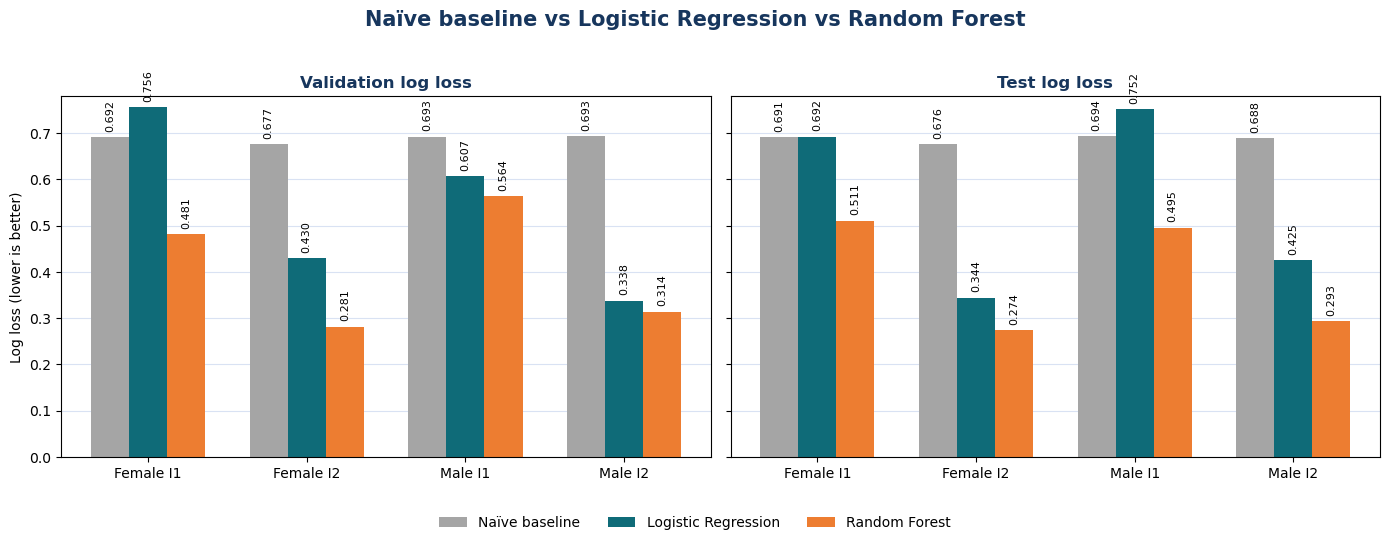

In [5]:
import matplotlib.pyplot as plt

NAVY = "#17365D"
COLORS = {
    "naive_baseline": "#A5A5A5",
    "logistic_regression": "#0F6B78",
    "random_forest": "#ED7D31",
}
DISPLAY_NAMES = {
    "naive_baseline": "Naïve baseline",
    "logistic_regression": "Logistic Regression",
    "random_forest": "Random Forest",
}
track_labels = ["Female I1", "Female I2", "Male I1", "Male I2"]
x = np.arange(len(TRACK_NAMES))
width = 0.24

fig, axes = plt.subplots(1, 2, figsize=(14, 5.4), sharey=True)
for ax, split_name in zip(axes, ["validation", "test"], strict=True):
    for offset, candidate in enumerate(CANDIDATES):
        values = [
            track_metrics[track]["performance"][f"{split_name}_log_loss"][candidate]
            for track in TRACK_NAMES
        ]
        bars = ax.bar(
            x + (offset - 1) * width,
            values,
            width,
            label=DISPLAY_NAMES[candidate],
            color=COLORS[candidate],
        )
        for bar, value in zip(bars, values, strict=True):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                value + 0.012,
                f"{value:.3f}",
                ha="center",
                va="bottom",
                rotation=90,
                fontsize=8,
            )
    ax.set_xticks(x, labels=track_labels)
    ax.set_ylim(0, 0.78)
    ax.set_title(f"{split_name.title()} log loss", fontweight="bold", color=NAVY)
    ax.grid(axis="y", color="#D9E2F3", linewidth=0.8)
    ax.set_axisbelow(True)
axes[0].set_ylabel("Log loss (lower is better)")
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, frameon=False, loc="lower center", ncol=3)
fig.suptitle(
    "Naïve baseline vs Logistic Regression vs Random Forest",
    fontsize=15,
    fontweight="bold",
    color=NAVY,
)
fig.tight_layout(rect=[0, 0.08, 1, 0.96])
plt.show()


### Selected-model feature profiles

Each panel reports the feature profile of the candidate selected on validation. Logistic Regression panels show signed coefficients; Random Forest panels show non-negative feature importances. One-hot team indicators may appear alongside numeric predictors. These are model associations, not causal effects.


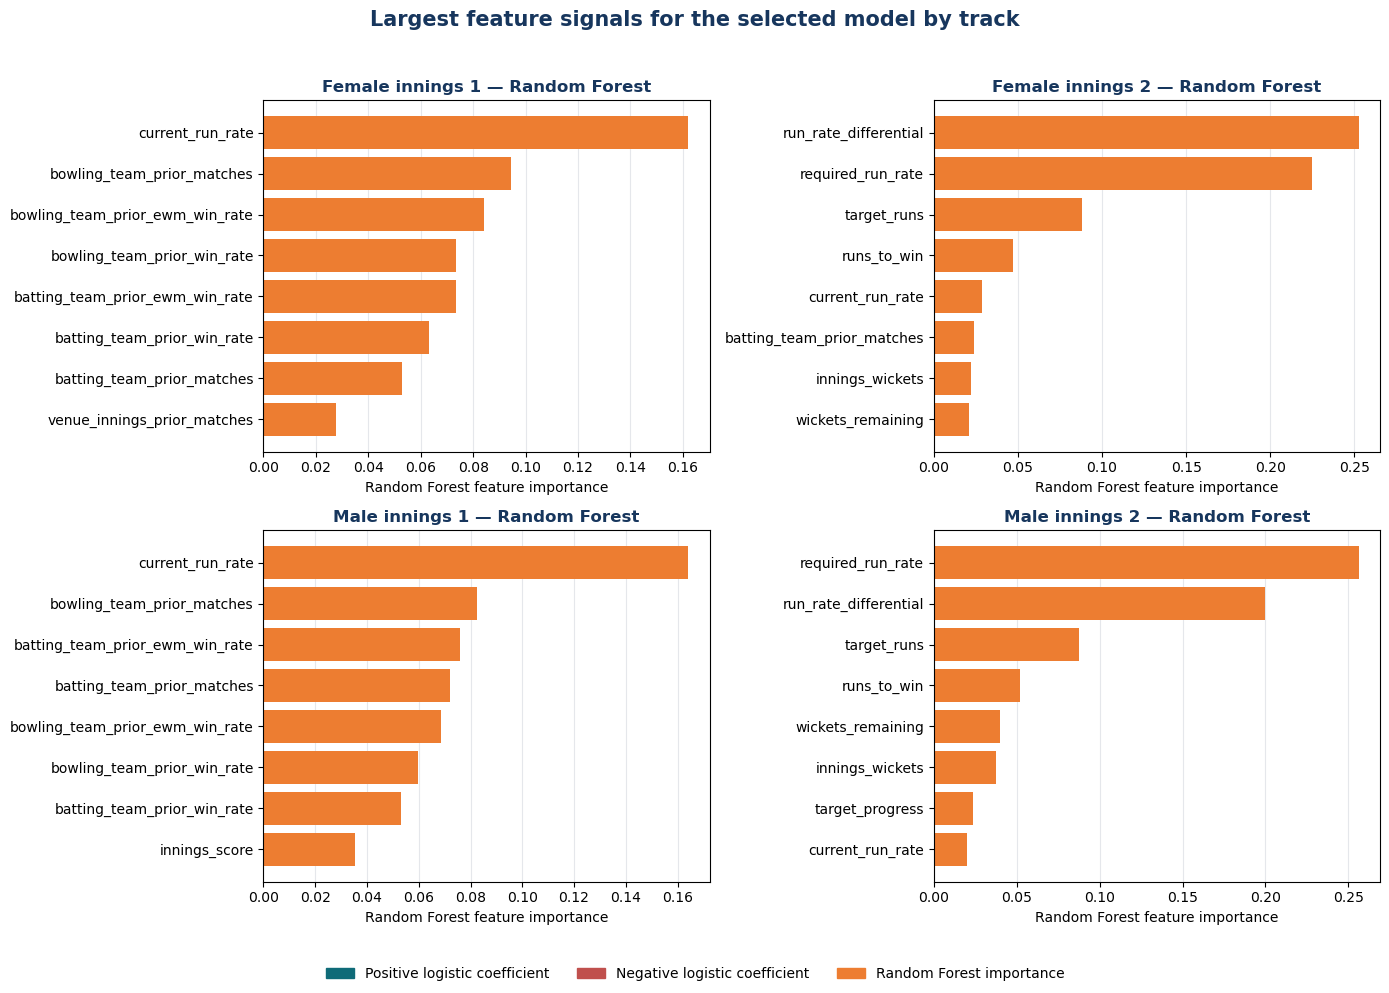

In [6]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

NAVY = "#17365D"
POSITIVE = "#0F6B78"
NEGATIVE = "#C0504D"
FOREST = "#ED7D31"
track_titles = ["Female innings 1", "Female innings 2", "Male innings 1", "Male innings 2"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, track_name, title in zip(axes.flat, TRACK_NAMES, track_titles, strict=True):
    selected = track_metrics[track_name]["selection"]["selected_model"]
    if selected == "logistic_regression":
        profile = pd.DataFrame(track_metrics[track_name]["top_logistic_coefficients"]).head(8)
        profile = profile.sort_values("absolute_coefficient")
        labels = profile["feature"].str.replace("missingindicator_", "missing: ", regex=False)
        values = profile["coefficient"]
        colors = [POSITIVE if value >= 0 else NEGATIVE for value in values]
        xlabel = "Logistic coefficient"
    elif selected == "random_forest":
        profile = pd.DataFrame(track_metrics[track_name]["top_random_forest_importances"]).head(8)
        profile = profile.sort_values("importance")
        labels = profile["feature"].str.replace("missingindicator_", "missing: ", regex=False)
        values = profile["importance"]
        colors = FOREST
        xlabel = "Random Forest feature importance"
    else:
        ax.text(0.5, 0.5, "Naïve baseline has no feature profile", ha="center", va="center")
        ax.set_axis_off()
        continue

    ax.barh(labels, values, color=colors)
    if selected == "logistic_regression":
        ax.axvline(0, color="#4B5563", linewidth=0.9)
    ax.set_title(f"{title} — {DISPLAY_NAMES[selected]}", fontweight="bold", color=NAVY)
    ax.set_xlabel(xlabel)
    ax.grid(axis="x", color="#E5E7EB", linewidth=0.8)
    ax.set_axisbelow(True)

fig.legend(
    handles=[
        Patch(color=POSITIVE, label="Positive logistic coefficient"),
        Patch(color=NEGATIVE, label="Negative logistic coefficient"),
        Patch(color=FOREST, label="Random Forest importance"),
    ],
    loc="lower center",
    ncol=3,
    frameon=False,
)
fig.suptitle(
    "Largest feature signals for the selected model by track",
    fontsize=15,
    fontweight="bold",
    color=NAVY,
)
fig.tight_layout(rect=[0, 0.05, 1, 0.96])
plt.show()


## 3. Save the Phase 04 performance record

The compact JSON contains log loss only, together with the candidate order, validation-based selection, test result, split policy, feature/null handling, and artifact paths required for reproduction.

In [7]:
phase_04_metrics = {
    "report_version": 2,
    "teacher_requirements": {
        "feature_data_dictionary_required": True,
        "candidate_order": CANDIDATES,
        "histogram_based_tree_used": False,
        "performance_metrics": ["log_loss"],
        "secondary_performance_metrics": [],
    },
    "source": {
        "phase_03_metrics_path": str(PHASE_03_METRICS_PATH.relative_to(PROJECT_ROOT)),
        "tracks": TRACK_NAMES,
    },
    "split_policy": {
        "unit": VALIDATION["split_unit"],
        "strategy": VALIDATION["split_strategy"],
        "equal_date_groups": VALIDATION["equal_date_groups"],
        "fractions": {
            "train": VALIDATION["train_fraction"],
            "validation": VALIDATION["validation_fraction"],
            "test": VALIDATION["test_fraction"],
        },
        "selection_split": "validation",
        "final_evaluation_split": "test",
    },
    "pre_innings_policy": {
        "included": True,
        "one_per_match_per_innings_track": True,
        "state_sequence": 0,
    },
    "preprocessing": {
        "shared_missing_values": MODEL_CONFIG["missing_values"],
        "logistic_regression_standardisation": "numeric_training_split_only",
        "categorical_encoding": {
            "columns": ["batting_team", "bowling_team"],
            "method": "one_hot",
            "handle_unknown": "ignore",
            "fit_scope": "training_split_only",
        },
    },
    "models": {
        "candidate_order": CANDIDATES,
        "naive_baseline": {"probability": "training_outcome_prevalence"},
        "logistic_regression": LOGISTIC_CONFIG,
        "random_forest": FOREST_CONFIG,
        "separate_probability_calibration": None,
        "sklearn_version": sklearn.__version__,
    },
    "quality_checks": {
        "same_gender_innings_share_cutoffs": True,
        "equal_date_group_isolation": True,
        "whole_match_split_isolation": True,
        "selection_uses_validation_only": True,
        "test_evaluated_after_selection": True,
        "unique_prediction_headers": True,
        "probabilities_in_unit_interval": True,
        "performance_metrics_reported": ["log_loss"],
        "team_identity_predictors_included": True,
        "categorical_encoder_fit_on_training_only": True,
        "track_specific_random_forest_parameters_recorded": True,
    },
    "tracks": track_metrics,
}

METRICS_PATH.parent.mkdir(parents=True, exist_ok=True)
METRICS_PATH.write_text(json.dumps(phase_04_metrics, indent=2, sort_keys=True) + "\n")

display(
    pd.DataFrame(
        [
            {
                "track": name,
                "features": values["feature_count"],
                "selected model": values["selection"]["selected_model"],
                "validation log loss": values["selection"]["selected_validation_log_loss"],
                "test log loss": values["selection"]["selected_test_log_loss"],
            }
            for name, values in track_metrics.items()
        ]
    )
)
print(f"Phase 04 metrics: {METRICS_PATH.relative_to(PROJECT_ROOT)}")


,track,features,selected model,validation log loss,test log loss
0,female_innings_1,38,random_forest,0.481027,0.510914
1,female_innings_2,43,random_forest,0.281434,0.273831
2,male_innings_1,38,random_forest,0.563600,0.495486
3,male_innings_2,43,random_forest,0.314362,0.292898


Phase 04 metrics: reports/metrics/phase_04_model_performance.json


## Phase-04 conclusion

Each of the four tracks now contains the required ordered comparison: naïve baseline, standalone logistic regression, and random forest. The selected model is determined exclusively by validation log loss and its test log loss is the final held-out result. Phase 05 must use `win_probability_selected` in source-event order and follow the approved attribution policy.